# VaR and ES-forecast
**Category: Quantiative Risk Management**

## Data & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stat

In [3]:
DAX = pd.read_csv("GDAXI.csv")
DAX = DAX.iloc[::-1].reset_index(drop=True)
DAX.head()

,Date,Open,High,Low,Close
0,01/03/00,6961.72,6750.76,6750.76,6750.76
1,01/04/00,6747.24,6586.95,6586.95,6586.95
2,01/05/00,6585.85,6502.07,6502.07,6502.07
3,01/06/00,6501.45,6474.92,6474.92,6474.92
4,01/07/00,6489.94,6780.96,6780.96,6780.96


In [4]:
add_yr = lambda series : ("20"+series.str[-2:]).astype(int)
ticks_loc = lambda df : [df[df["Year"] == y].index[0] for y in np.unique(df["Year"])]
DAX["Year"] = add_yr(DAX["Date"])
DAX_ticks = ticks_loc(DAX)
DAX_ticks_shifted = [t + 1 for t in ticks_loc(DAX)]



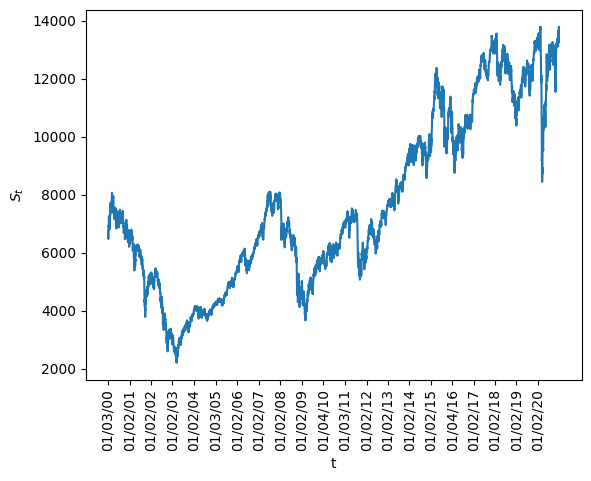

In [5]:
plt.plot(DAX["Date"],DAX[" Close"])
plt.xticks(DAX["Date"][DAX_ticks],rotation=90)
plt.xlabel("t")
plt.ylabel(fr"$S_t$")
plt.show()

In [6]:
t = 1270
print(DAX["Date"][:t])

0       01/03/00
1       01/04/00
2       01/05/00
3       01/06/00
4       01/07/00
          ...   
1265    12/23/04
1266    12/27/04
1267    12/28/04
1268    12/29/04
1269    12/30/04
Name: Date, Length: 1270, dtype: str


In [7]:
DAX["Train"] = np.append(DAX[" Close"][:t],np.full_like(DAX[" Close"][t:],np.NaN))
DAX["Test"] = np.append(np.full_like(DAX[" Close"][:t-1],np.NaN),DAX[" Close"][t-1:])

print(DAX[t-10:t+10])

          Date     Open     High      Low    Close  Year    Train     Test
1260  12/16/04  4216.36  4233.71  4233.71  4233.71  2004  4233.71      NaN
1261  12/17/04  4235.78  4182.27  4182.27  4182.27  2004  4182.27      NaN
1262  12/20/04  4178.17  4211.55  4211.55  4211.55  2004  4211.55      NaN
1263  12/21/04  4201.43  4214.39  4214.39  4214.39  2004  4214.39      NaN
1264  12/22/04  4232.44  4241.28  4241.28  4241.28  2004  4241.28      NaN
1265  12/23/04  4234.05  4251.62  4251.62  4251.62  2004  4251.62      NaN
1266  12/27/04  4254.41  4235.36  4235.36  4235.36  2004  4235.36      NaN
1267  12/28/04  4253.81  4261.79  4261.79  4261.79  2004  4261.79      NaN
1268  12/29/04  4270.56  4247.75  4247.75  4247.75  2004  4247.75      NaN
1269  12/30/04  4254.38  4256.08  4256.08  4256.08  2004  4256.08  4256.08
1270  01/03/05  4260.92  4291.53  4291.53  4291.53  2005      NaN  4291.53
1271  01/04/05  4281.63  4290.50  4290.50  4290.50  2005      NaN  4290.50
1272  01/05/05  4262.21  

In [8]:
log_return = lambda series : np.log(series/series.shift(1))

In [9]:
# L = -100*log_return(DAX[" Close"])
DAX["L test"] = -100*log_return(DAX["Test"])
DAX["L train"] = -100*log_return(DAX["Train"])
DAX["L full"] = -100*log_return(DAX[" Close"])


In [10]:
print(DAX[t-10:t+10])

          Date     Open     High      Low    Close  Year    Train     Test  \
1260  12/16/04  4216.36  4233.71  4233.71  4233.71  2004  4233.71      NaN   
1261  12/17/04  4235.78  4182.27  4182.27  4182.27  2004  4182.27      NaN   
1262  12/20/04  4178.17  4211.55  4211.55  4211.55  2004  4211.55      NaN   
1263  12/21/04  4201.43  4214.39  4214.39  4214.39  2004  4214.39      NaN   
1264  12/22/04  4232.44  4241.28  4241.28  4241.28  2004  4241.28      NaN   
1265  12/23/04  4234.05  4251.62  4251.62  4251.62  2004  4251.62      NaN   
1266  12/27/04  4254.41  4235.36  4235.36  4235.36  2004  4235.36      NaN   
1267  12/28/04  4253.81  4261.79  4261.79  4261.79  2004  4261.79      NaN   
1268  12/29/04  4270.56  4247.75  4247.75  4247.75  2004  4247.75      NaN   
1269  12/30/04  4254.38  4256.08  4256.08  4256.08  2004  4256.08  4256.08   
1270  01/03/05  4260.92  4291.53  4291.53  4291.53  2005      NaN  4291.53   
1271  01/04/05  4281.63  4290.50  4290.50  4290.50  2005      Na

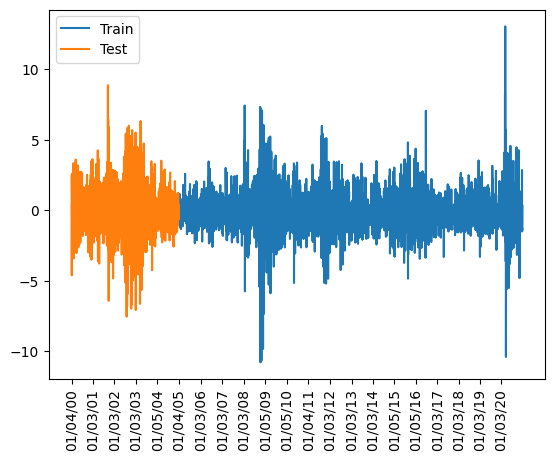

In [11]:
plt.plot(DAX["Date"],DAX["L test"],label="Train")
plt.plot(DAX["Date"],DAX["L train"],label="Test")

plt.xticks(DAX["Date"][DAX_ticks_shifted],rotation=90)
plt.legend()
plt.show()

### Expected Shortfall and VaR

In [12]:
alpha = 0.025
p = 1-alpha

In [13]:
DAX.head()

,Date,Open,High,Low,Close,Year,Train,Test,L test,L train,L full
0,01/03/00,6961.72,6750.76,6750.76,6750.76,2000,6750.76,NaN,NaN,NaN,NaN
1,01/04/00,6747.24,6586.95,6586.95,6586.95,2000,6586.95,NaN,NaN,2.456467,2.456467
2,01/05/00,6585.85,6502.07,6502.07,6502.07,2000,6502.07,NaN,NaN,1.296983,1.296983
3,01/06/00,6501.45,6474.92,6474.92,6474.92,2000,6474.92,NaN,NaN,0.418434,0.418434
4,01/07/00,6489.94,6780.96,6780.96,6780.96,2000,6780.96,NaN,NaN,-4.618243,-4.618243


#### Covariance-Variance Method

In [14]:
mu =DAX["L train"].mean()
sigma_2 = DAX["L train"].var()
print(mu)
print(np.sqrt(sigma_2))

0.03635197338721809
1.836353743407955


Note for $X\sim\mathcal{N}(\mu,\sigma^2)$, we can take 

$$\text{VaR}_{\alpha}(X) = \mu+\sigma\Phi^{-1}(\alpha)$$


Since $Z = \frac{X-\mu}{\sigma}\sim \mathcal{N}(0,1)$, hence $X = \mu+\sigma Z$, and with trivial computations

$$ES_{\alpha}(Z) = \mathbb{E}[Z|Z\geq \text{VaR}_{\alpha}] = \frac{\int^{\infty}_{-\Phi^{-1}(\alpha)}z\varphi(z)dz}{1-\alpha} = \frac{\varphi(\Phi^{-1}(\alpha))}{1-\alpha}$$

3.635539173342118
4.3293848821958525


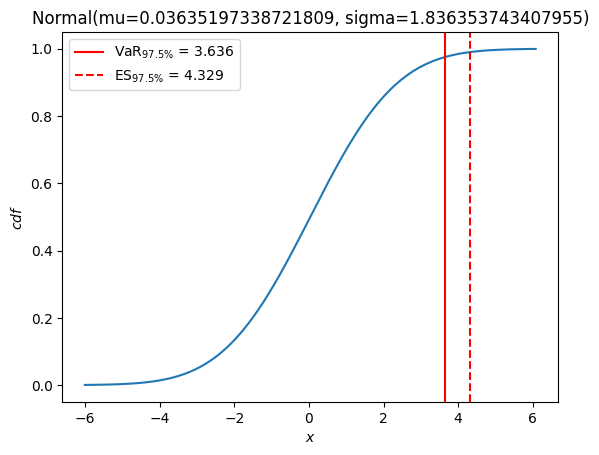

In [15]:
L_dist = stat.Normal(mu=mu,sigma=np.sqrt(sigma_2))
VaR_975_cv = mu+np.sqrt(sigma_2)*stat.norm.ppf(p)
ES_975_cv = mu+(np.sqrt(sigma_2)*stat.norm.pdf(stat.norm.ppf(p)))/(1-p)
print(VaR_975_cv)
print(ES_975_cv)

L_dist.plot(y='cdf')
plt.axvline(VaR_975_cv,color="red",label=fr"VaR$_{{97.5\%}}$ = {round(VaR_975_cv,3)}")
plt.axvline(ES_975_cv,color='red',linestyle='--',label=fr"ES$_{{97.5\%}}$ = {round(ES_975_cv,3)}")

plt.legend()
plt.show()

#### Historical Simulation

3.953100408427189
5.049904521525052


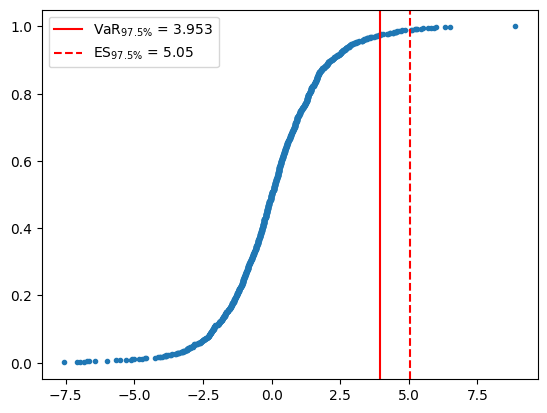

1.0873491440866911
1.1664254065958104


In [16]:
L_train = DAX["L train"].dropna()
historical_train = L_train.value_counts(normalize=True).sort_index()
hist_cdf_train = np.cumsum(historical_train.values)
VaR_975_hist = np.quantile(L_train,p,method="higher")
ES_975_hist = np.mean(historical_train.index[historical_train.index>=VaR_975_hist])
plt.plot(historical_train.index,hist_cdf_train,'.')
print(VaR_975_hist)
print(ES_975_hist)
plt.axvline(VaR_975_hist,color="red",label=fr"VaR$_{{97.5\%}}$ = {round(VaR_975_hist,3)}")
plt.axvline(ES_975_hist,color='red',linestyle='--',label=fr"ES$_{{97.5\%}}$ = {round(ES_975_hist,3)}")
plt.legend()
plt.show()

print(VaR_975_hist/VaR_975_cv)
print(ES_975_hist/ES_975_cv)


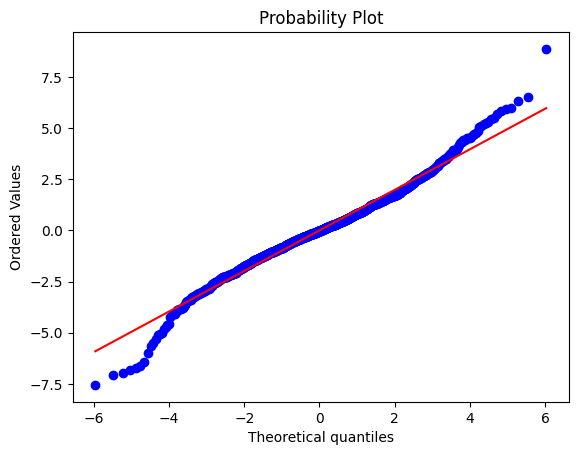

In [17]:
stat.probplot(L_train,sparams=(mu,np.sqrt(sigma_2)),plot=plt)
plt.show()

#### Comparison

**Covariance-Variance method under the normality assumption**

* It is very nice mathematically, but it is clear from above that it totally underestimates tails, with the VaR being approximately $9\%$ smaller and the expected shortfall almost $17\%$ smaller than what is observed using the historical estimate. Eventhough the historical estimate isn't perfect, looking at an underestimate of a risk measure of potentially $17\%$ is severe.

* One noticable aspect is that these are daily values, hence the amount of data is not small in comparison to longer period, the conclusion is simple that if we compare these on shorter periods the historical simulation should always be a clear winner, assuming one wants to mitigate risks (not be neutral or seeking).

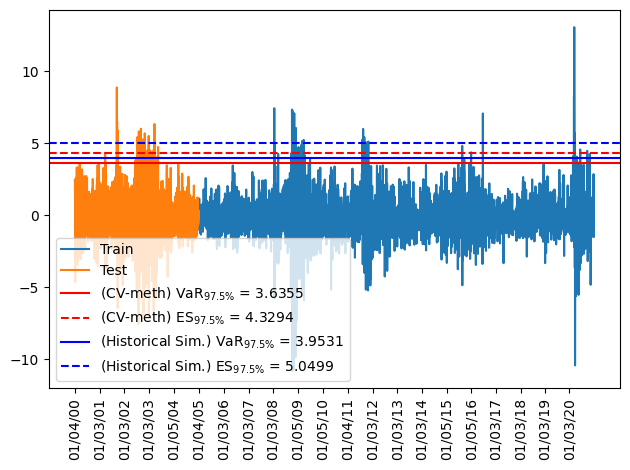

In [18]:

plt.plot(DAX["Date"],DAX["L test"],label="Train")
plt.plot(DAX["Date"],DAX["L train"],label="Test")

plt.xticks(DAX["Date"][DAX_ticks_shifted],rotation=90)
plt.legend()
plt.axhline(VaR_975_cv,color="red",label=fr"(CV-meth) VaR$_{{97.5\%}}$ = {round(VaR_975_cv,4)}")
plt.axhline(ES_975_cv,color='red',linestyle='--',label=fr"(CV-meth) ES$_{{97.5\%}}$ = {round(ES_975_cv,4)}")
plt.axhline(VaR_975_hist,color="blue",label=fr"(Historical Sim.) VaR$_{{97.5\%}}$ = {round(VaR_975_hist,4)}")
plt.axhline(ES_975_hist,color='blue',linestyle='--',label=fr"(Historical Sim.) ES$_{{97.5\%}}$ = {round(ES_975_hist,4)}")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [19]:
def aboveVaR(df_col,VaR):
    n = len(df_col.dropna())
    m = len(df_col[df_col>=VaR])
    return m/n*100

def lossES(df_col,VaR):
    m = df_col[df_col>=VaR].sum()
    return m

print("CV VaR comparison:\n\t" +
      f"Test: {round(aboveVaR(DAX['L test'],VaR_975_cv),3)}%\n\t"+
      f"Train: {round(aboveVaR(DAX['L train'],VaR_975_cv),3)}%")

print("HIST VaR comparison:\n\t" +
      f"Test: {round(aboveVaR(DAX['L test'],VaR_975_hist),3)}%\n\t"+
      f"Train: {round(aboveVaR(DAX['L train'],VaR_975_hist),3)}%")

print("CV ES comparison:\n\t" +
      f"Test: {round(lossES(DAX['L test'],VaR_975_cv),3)}\n\t"+
      f"Train: {round(lossES(DAX['L train'],VaR_975_cv),3)}")

print("HIST ES comparison:\n\t" +
      f"Test: {round(lossES(DAX['L test'],VaR_975_hist),3)}\n\t"+
      f"Train: {round(lossES(DAX['L train'],VaR_975_hist),3)}")




CV VaR comparison:
	Test: 1.207%
	Train: 3.152%
HIST VaR comparison:
	Test: 1.034%
	Train: 2.522%
CV ES comparison:
	Test: 255.874
	Train: 192.19
HIST ES comparison:
	Test: 229.303
	Train: 161.597


There are a few things to consider, namely:
* It is clear that the Covariance-Variance method severely underestimates the tail exposure on the training data, and it happens to be so that it is fine WHEN comparing the value at risk, however the actual amount lost is alot higher in the testing regime vs training regime, (it is significant as well when one looks as the historical simulation).
* Both methods would need some calibration, the current setting is far from optimal, on hand it might be extremely costly to underestimate exposure, on the other the assumption that the daily market data behaves in the same manner as it did several (at most 15) years ago is asburd. Even a very slight calibration would yield to much tighter bounds (keeping exposure limited, whilst not limiting returns totally).

### Dynamic risk measure modelling

In [20]:
from arch import arch_model
model = arch_model(L_train,p=1,q=1,vol="GARCH")
res = model.fit(disp='off')
print(res.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                L train   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2373.63
Distribution:                  Normal   AIC:                           4755.25
Method:            Maximum Likelihood   BIC:                           4775.84
                                        No. Observations:                 1269
Date:                Tue, Apr 07 2026   Df Residuals:                     1268
Time:                        12:35:17   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu            -0.0164  3.698e-02     -0.444      0.657 

In [21]:
print(res.params.keys())

Index(['mu', 'omega', 'alpha[1]', 'beta[1]'], dtype='str')


In [22]:
alpha0 = res.params["omega"]; alpha1 = res.params["alpha[1]"]; beta = res.params["beta[1]"]
print(alpha0,alpha1,beta)

0.02252653476966158 0.0915772042990429 0.9019353539723943


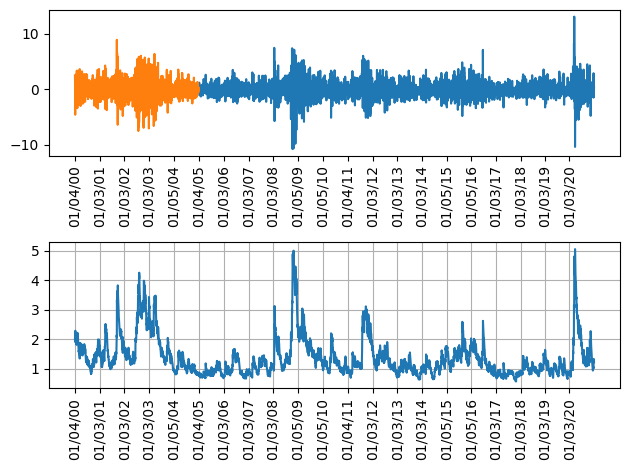

In [23]:
L_test = DAX['L test'].dropna()
L_full = DAX["L full"].dropna()
Sigma = np.zeros_like(L_full)
Sigma[0:len(L_train)] = res.conditional_volatility
for i in range(len(L_test)):
    L = L_test[i+len(L_train)+1]
    Sigma[i+len(L_train)] = np.sqrt(alpha0+alpha1*L**2+beta*Sigma[i+len(L_train)-1]**2)


DAX["Vola"] = np.append(np.NaN,Sigma)
plt.subplot(2,1,1)
plt.plot(DAX["Date"],DAX["L test"],label="Train")
plt.plot(DAX["Date"],DAX["L train"],label="Test")
plt.xticks(DAX["Date"][DAX_ticks_shifted],rotation=90)

plt.subplot(2,1,2)
plt.plot(DAX["Date"],DAX["Vola"])
plt.grid()
plt.xticks(DAX["Date"][DAX_ticks_shifted],rotation=90)

plt.tight_layout()
plt.show()

We recall the 6 stylized facts for the univariate case:

* (U1): Returns are not iid although they show little serial correlation 
* (U2): Series of absolute or squared returns show profound serial correlation 
* (U3): Conditional expected returns are close to zero 
* (U4): Volatility (conditional standard deviation) appears to vary over time 
* (U5): Extreme returns appear in clusters 
* (U6): Return series are leptokurtic or heavy-tailed (power-like tail)


* (U1): We need acf/pacf analysis to come to a conclusion
* (U2): We need further analusis to come to a conclusion
* (U3): This is indeed the case 
* (U4): This is very clear from the above
* (U5): This is very clear as well
* (U6): This is is the case, however we would need further analysis to come to a clearer conclusion (the above gives strong hints, same for training data plot)

0.031051438972395377 1.0001621217545789


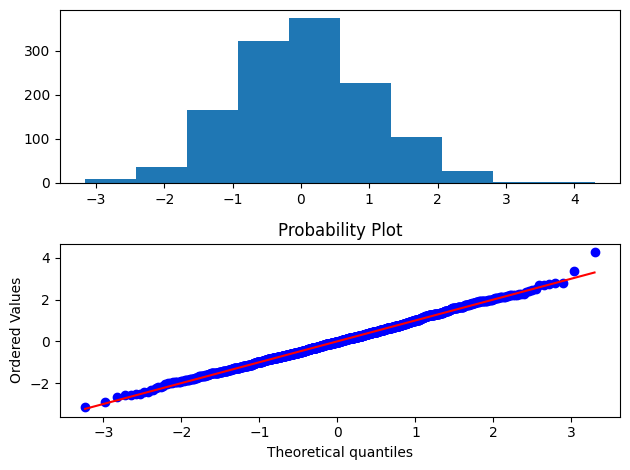

In [24]:
Z_hat = L_train/Sigma[0:t-1]
mu_z = Z_hat.mean()
sigma_z = Z_hat.std(ddof=1)
print(mu_z,sigma_z)
plt.subplot(2,1,1)
plt.hist(Z_hat)
plt.subplot(2,1,2)
stat.probplot(Z_hat,sparams=(mu_z,sigma_z),plot=plt)
plt.tight_layout()
plt.show()


Roughly speaking the residuals seem to come from a normal distribution, we still note the two outliers in the upper right corner (could be coincidence).

In [ ]:
VaR_975_z_cv = mu_z+(sigma_z)*stat.norm.ppf(p)
ES_975_z_cv = mu_z+(sigma_z*stat.norm.pdf(stat.norm.ppf(p)))/(1-p)
VaR_975_z_hist = np.quantile(Z_hat,p,method="higher")
ES_975_z_hist = np.mean(Z_hat[Z_hat>=VaR_975_z_hist])
print(VaR_975_z_cv,ES_975_z_cv)
print(VaR_975_z_hist,ES_975_z_hist)

1.9913331763125346 2.36923323986434
2.0057147437554135 2.3860799025559283


In [71]:
def cv_meth(mu,vol):
    VaR_975_cv,ES_975_cv = mu+(vol)*stat.norm.ppf(p), mu+(vol*stat.norm.pdf(stat.norm.ppf(p)))/(1-p)
    return VaR_975_cv,ES_975_cv

def hist_meth(VaR_975_z_hist,ES_975_z_hist,vol):
    VaR_975_hist,ES_975_hist = vol*VaR_975_z_hist,vol*ES_975_z_hist
    return VaR_975_hist,ES_975_hist

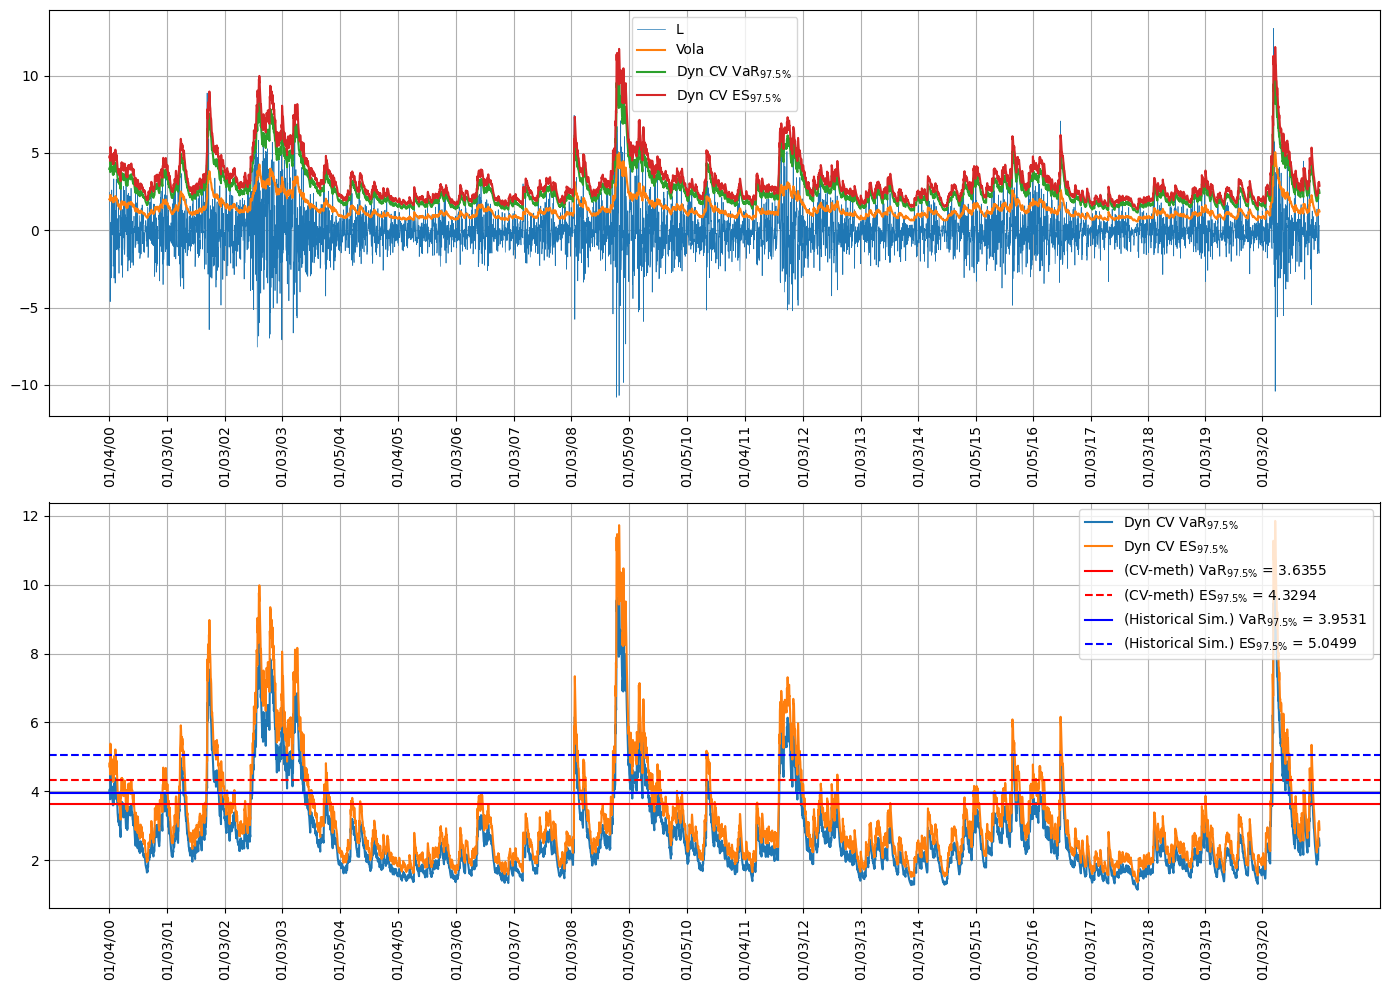

In [74]:
VaR_975_cv_dyn,ES_975_cv_dyn = cv_meth(mu,Sigma)
DAX["Dyn CV VaR"] = np.append(np.NaN,VaR_975_cv_dyn)
DAX["Dyn CV ES"] = np.append(np.NaN,ES_975_cv_dyn)

VaR_975_hist_dyn,ES_975_hist_dyn = hist_meth(VaR_975_z_hist,ES_975_z_hist,Sigma)
DAX["Dyn HIST VaR"] = np.append(np.NaN,VaR_975_hist_dyn)
DAX["Dyn HIST ES"] = np.append(np.NaN,ES_975_hist_dyn)


fig = plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
plt.plot(DAX["Date"],DAX["L full"],label="L",lw=0.5)
plt.plot(DAX["Date"],DAX["Vola"],label="Vola")
plt.plot(DAX["Date"],DAX["Dyn CV VaR"],label=f"Dyn CV VaR$_{{97.5\%}}$")
plt.plot(DAX["Date"],DAX["Dyn CV ES"],label=f"Dyn CV ES$_{{97.5\%}}$")
plt.xticks(DAX["Date"][DAX_ticks_shifted],rotation=90)
plt.legend()
plt.grid()

plt.subplot(2,1,2)

# plt.plot(DAX["Date"],DAX["Dyn HIST VaR"],label=f"Dyn HIST VaR$_{{97.5\%}}$")
# plt.plot(DAX["Date"],DAX["Dyn HIST ES"],label=f"Dyn HIST ES$_{{97.5\%}}$")
plt.plot(DAX["Date"],DAX["Dyn CV VaR"],label=f"Dyn CV VaR$_{{97.5\%}}$")
plt.plot(DAX["Date"],DAX["Dyn CV ES"],label=f"Dyn CV ES$_{{97.5\%}}$")

plt.axhline(VaR_975_cv,color="red",label=fr"(CV-meth) VaR$_{{97.5\%}}$ = {round(VaR_975_cv,4)}")
plt.axhline(ES_975_cv,color='red',linestyle='--',label=fr"(CV-meth) ES$_{{97.5\%}}$ = {round(ES_975_cv,4)}")
plt.axhline(VaR_975_hist,color="blue",label=fr"(Historical Sim.) VaR$_{{97.5\%}}$ = {round(VaR_975_hist,4)}")
plt.axhline(ES_975_hist,color='blue',linestyle='--',label=fr"(Historical Sim.) ES$_{{97.5\%}}$ = {round(ES_975_hist,4)}")
plt.xticks(DAX["Date"][DAX_ticks_shifted],rotation=90)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

* It is clear that the dynamic risk measure approachis extremely sensitive to the data, whereas the static one is a smoothed out version, hence not as conservative during higher volatility regimes, but too conservative during lower volatility regimes.
* Solely based on this comparison one would use a dynamic approach. We still note that with the covariance-variance method there are two major drawbacks, first of all in reality estimating the Covariance-Variance matrix adequately is highly non-trivial task, secondly, the normality assumption is still way too thin on the tails, as can be observed during very high volatility regimes, finding the "correct" distribution is also a highly non-trivial task.

All in all, one could start with simplistic approaches as done above, but should carefully think about the underlying assumptions. 
